# 📉 DoNext 5G — NB4_DSO2 : Prédiction RSRP Drop

**Pipeline :** NB1 ✅ → NB2 ✅ → NB3 ✅ → DSO1 ✅ → **NB4_DSO2**

---
### 🎯 Objectif
Prédire si le signal RSRP va chuter de plus de **-6 dBm** dans les **5 prochaines mesures**.

### 📊 Label DSO2
```
rsrp_drop = 1  si  min(rsrp[t+1..t+5]) - rsrp[t] < -6 dBm
rsrp_drop = 0  sinon
```
Construit depuis `df_final_fe.parquet` (NB2) sur la colonne `rsrp` brute.

### ✅ CORRECTIONS APPORTÉES
1. **Setup** : Vérification `cluster_id` dans `COLS_X`
2. **Label** : Calcul depuis `df_final_fe` (rsrp brut NB2, pas normalisé)
3. **BiLSTM** : Bug corrigé `_t-{k}` → `_T{k}` (format NB2)
4. **TabNet** : `pretrainer` défini AVANT son utilisation (déjà correct)
5. **Noms fichiers** : Identiques à l'original (`xgb_dso2.pkl`, `lgbm_dso2.pkl`...)


---
## Section 0 — Setup


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import json, os, gc, pickle, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer
import torch

plt.rcParams.update({
    'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27',
    'axes.edgecolor':'#3A3D4D','axes.labelcolor':'#E0E0E0',
    'axes.titlecolor':'#FFFFFF','xtick.color':'#B0B0B0',
    'ytick.color':'#B0B0B0','text.color':'#E0E0E0',
    'grid.color':'#2A2D3A','grid.linestyle':'--',
    'grid.alpha':0.5,'font.family':'monospace','figure.dpi':130
})
BLUE='#4FC3F7'; GREEN='#69F0AE'; ORANGE='#FFB74D'
RED='#EF5350'; PURPLE='#CE93D8'
CM_LABELS = ['No Drop', 'Drop']

DATASET_ROOT  = r'C:\Users\THINKPAD\Desktop\DATASET'
PT_OUT_DIR    = os.path.join(DATASET_ROOT, 'PT_output')
FE_OUT_DIR    = os.path.join(DATASET_ROOT, 'FE_output')
MODEL_OUT_DIR = os.path.join(DATASET_ROOT, 'MODEL_output', 'DSO2')
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

print('✅ Setup OK')

✅ Setup OK


---
## Section 1 — Construction du Label RSRP Drop


In [2]:
# ── Paramètres label DSO2 ─────────────────────────────────────
# Référence: 3GPP TS 38.331 — Event A2 (RSRP below threshold)
# Un drop = chute de signal de plus de 6 dBm
# dans les 5 prochaines mesures
SEUIL_DBM = -6.0   # seuil de chute RSRP
HORIZON   = 5      # fenêtre de prédiction
CONFIGS   = {'static':'session_id','mobile':'device','hbahn':'device'}

# ✅ CORRECTION:
# Charger rsrp depuis df_final_fe (BRUT, pas normalisé!)
# NB3 normalise rsrp → valeurs entre 0 et 1
# On ne peut pas détecter -6 dBm sur des valeurs normalisées
print('Chargement rsrp brut depuis df_final_fe.parquet...')
df_fe = pd.read_parquet(
    os.path.join(FE_OUT_DIR, 'df_final_fe.parquet'),
    columns=['rsrp', 'session_id', 'source_folder', 'device']
)
df_fe = df_fe.reset_index(drop=True)
df_fe['rsrp_drop'] = 0

# Charger df_preprocessed pour les features
print('Chargement df_preprocessed.parquet...')
df = pd.read_parquet(
    os.path.join(PT_OUT_DIR, 'df_preprocessed.parquet')
)

print(f'\nSeuil={SEUIL_DBM} dBm | Horizon={HORIZON}')
print(f'RSRP brut: min={df_fe["rsrp"].min():.1f} max={df_fe["rsrp"].max():.1f}')

# Calcul label rsrp_drop par environnement
for env, cle in CONFIGS.items():
    if cle not in df_fe.columns:
        continue
    mask_env = df_fe['source_folder'] == env
    for _, grp in df_fe[mask_env].groupby(cle):
        rsrp_v = grp['rsrp'].values
        idxs   = grp.index
        n      = len(rsrp_v)
        for i in range(n - HORIZON):
            futur = rsrp_v[i+1:i+1+HORIZON]
            if (futur.min() - rsrp_v[i]) < SEUIL_DBM:
                df_fe.at[idxs[i], 'rsrp_drop'] = 1

    nd  = df_fe.loc[mask_env, 'rsrp_drop'].sum()
    nt  = mask_env.sum()
    print(f'  {env}: {nd:,} drops ({nd/nt*100:.1f}%)')

total_drop = df_fe['rsrp_drop'].sum()
total      = len(df_fe)
ratio_drop = int((total - total_drop) / max(total_drop, 1))
print(f'\nTOTAL {total_drop:,}/{total:,} ({total_drop/total*100:.2f}%)')
print(f'Ratio 1:{ratio_drop}')

# Affecter label dans df
df['rsrp_drop'] = df_fe['rsrp_drop'].values
print(f'\n✅ Label rsrp_drop créé')
del df_fe
gc.collect()

Chargement rsrp brut depuis df_final_fe.parquet...
Chargement df_preprocessed.parquet...

Seuil=-6.0 dBm | Horizon=5
RSRP brut: min=-140.0 max=-44.0
  static: 20,197 drops (0.2%)
  mobile: 346,458 drops (14.5%)
  hbahn: 104,042 drops (21.0%)

TOTAL 470,697/12,602,863 (3.73%)
Ratio 1:25

✅ Label rsrp_drop créé


0

In [3]:
# ── Chargement features + splits ──────────────────────────────
idx_train = np.load(os.path.join(PT_OUT_DIR,'idx_train.npy'), allow_pickle=True)
idx_val   = np.load(os.path.join(PT_OUT_DIR,'idx_val.npy'),   allow_pickle=True)
idx_test  = np.load(os.path.join(PT_OUT_DIR,'idx_test.npy'),  allow_pickle=True)

with open(os.path.join(PT_OUT_DIR,'config.json')) as f:
    config = json.load(f)

# ✅ CORRECTION: cluster_id doit être dans COLS_X
COLS_X = [
    c for c in config['cols_X']
    if c in df.columns and c != 'rsrp_drop'
]
print(f'Vérifications:')
print(f'  cluster_id dans COLS_X: {"cluster_id" in COLS_X}')
print(f'  Total features: {len(COLS_X)}')

assert 'cluster_id' in COLS_X, \
    '❌ cluster_id absent! Relancer NB3 corrigé.'

# Labels DSO2
y_train = df.loc[idx_train, 'rsrp_drop'].values
y_val   = df.loc[idx_val,   'rsrp_drop'].values
y_test  = df.loc[idx_test,  'rsrp_drop'].values

# Features
X_train = df.loc[idx_train, COLS_X].values.astype(np.float32)
X_val   = df.loc[idx_val,   COLS_X].values.astype(np.float32)
X_test  = df.loc[idx_test,  COLS_X].values.astype(np.float32)

ratio = int((1 - y_train.mean()) / max(y_train.mean(), 1e-6))
print(f'\n✅ X_train {X_train.shape}')
print(f'   Drop%={y_train.mean()*100:.2f}% | ratio 1:{ratio}')

Vérifications:
  cluster_id dans COLS_X: True
  Total features: 101

✅ X_train (8822003, 101)
   Drop%=3.97% | ratio 1:24


---
## Section 2 — M1 : XGBoost


In [4]:
print('='*60+'\n  M1 — XGBoost DSO2\n'+'='*60)

xgb_d2 = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=ratio, eval_metric='aucpr',
    early_stopping_rounds=30, tree_method='hist',
    random_state=42, n_jobs=-1, use_label_encoder=False
)
xgb_d2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], verbose=50
)
y_pred_xgb = xgb_d2.predict(X_test)
y_prob_xgb = xgb_d2.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_xgb, target_names=CM_LABELS))

metrics_xgb = {
    'model':     'XGBoost',
    'f1':        round(f1_score(y_test, y_pred_xgb), 4),
    'precision': round(precision_score(y_test, y_pred_xgb), 4),
    'recall':    round(recall_score(y_test, y_pred_xgb), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_xgb), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_xgb), 4)
}
# ✅ même nom que l'original
with open(os.path.join(MODEL_OUT_DIR,'xgb_dso2.pkl'),'wb') as f:
    pickle.dump(xgb_d2, f)
print(f"  XGBoost F1={metrics_xgb['f1']} AUC-PR={metrics_xgb['auc_pr']}")

  M1 — XGBoost DSO2
[0]	validation_0-aucpr:0.37707
[50]	validation_0-aucpr:0.46982
[100]	validation_0-aucpr:0.49261
[150]	validation_0-aucpr:0.50412
[200]	validation_0-aucpr:0.51013
[250]	validation_0-aucpr:0.51418
[300]	validation_0-aucpr:0.51662
[350]	validation_0-aucpr:0.51860
[400]	validation_0-aucpr:0.51949
[450]	validation_0-aucpr:0.52174
[499]	validation_0-aucpr:0.52270
              precision    recall  f1-score   support

     No Drop       1.00      0.84      0.91   1824958
        Drop       0.17      0.96      0.29     65474

    accuracy                           0.84   1890432
   macro avg       0.59      0.90      0.60   1890432
weighted avg       0.97      0.84      0.89   1890432

  XGBoost F1=0.294 AUC-PR=0.4499


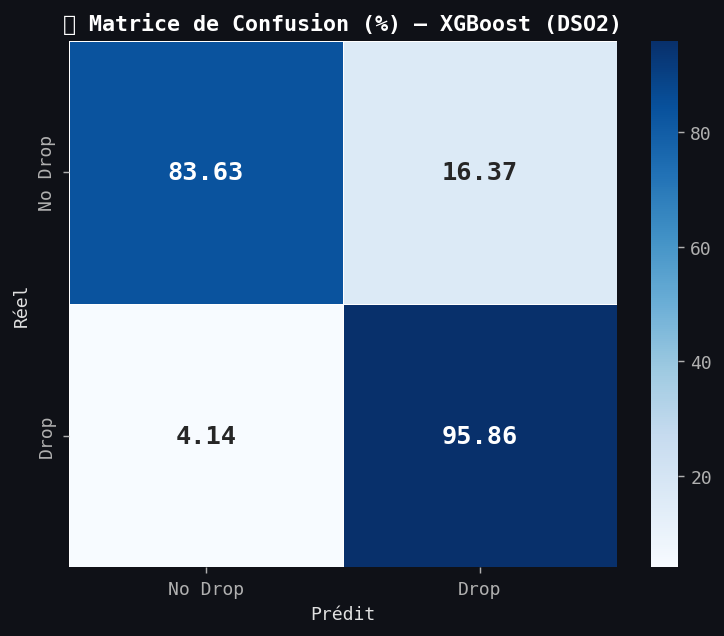

VN:83.6% FP:16.4% FN:4.1% VP:95.9%


In [5]:
# ── Matrice de Confusion — XGBoost ───────────────────────────
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_pct = cm_xgb.astype('float') / cm_xgb.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_pct*100, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CM_LABELS, yticklabels=CM_LABELS,
    linewidths=0.5, ax=ax, annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title('📊 Matrice de Confusion (%) — XGBoost (DSO2)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_xgb_dso2_pct.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f"VN:{cm_pct[0,0]*100:.1f}% FP:{cm_pct[0,1]*100:.1f}% "
      f"FN:{cm_pct[1,0]*100:.1f}% VP:{cm_pct[1,1]*100:.1f}%")

---
## Section 3 — M2 : LightGBM


In [6]:
print('='*60+'\n  M2 — LightGBM DSO2\n'+'='*60)

lgbm_d2 = LGBMClassifier(
    n_estimators=500, max_depth=7, learning_rate=0.05,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    is_unbalance=True, metric='average_precision',
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_d2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(30, verbose=False),
        lgb.log_evaluation(50)
    ]
)
y_pred_lgbm = lgbm_d2.predict(X_test)
y_prob_lgbm = lgbm_d2.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_lgbm, target_names=CM_LABELS))

metrics_lgbm = {
    'model':     'LightGBM',
    'f1':        round(f1_score(y_test, y_pred_lgbm), 4),
    'precision': round(precision_score(y_test, y_pred_lgbm), 4),
    'recall':    round(recall_score(y_test, y_pred_lgbm), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_lgbm), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_lgbm), 4)
}
# ✅ même nom que l'original
with open(os.path.join(MODEL_OUT_DIR,'lgbm_dso2.pkl'),'wb') as f:
    pickle.dump(lgbm_d2, f)
print(f"  LightGBM F1={metrics_lgbm['f1']} AUC-PR={metrics_lgbm['auc_pr']}")

  M2 — LightGBM DSO2
[50]	valid_0's average_precision: 0.484554
[100]	valid_0's average_precision: 0.506097
[150]	valid_0's average_precision: 0.51492
[200]	valid_0's average_precision: 0.49669
              precision    recall  f1-score   support

     No Drop       1.00      0.83      0.91   1824958
        Drop       0.17      0.97      0.29     65474

    accuracy                           0.83   1890432
   macro avg       0.58      0.90      0.60   1890432
weighted avg       0.97      0.83      0.88   1890432

  LightGBM F1=0.2878 AUC-PR=0.4423


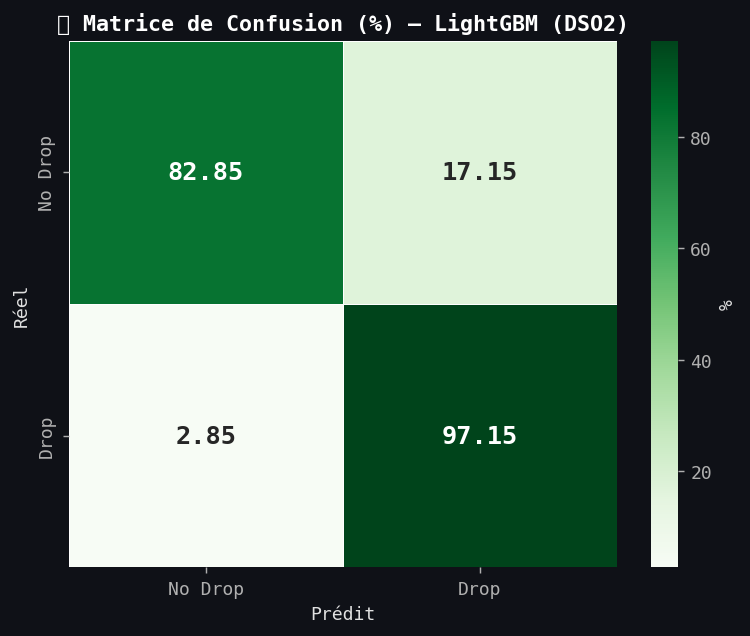

VN:82.9% FP:17.1% FN:2.8% VP:97.2%


In [7]:
# ── Matrice de Confusion — LightGBM ──────────────────────────
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
cm_pct  = cm_lgbm.astype('float') / cm_lgbm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_pct*100, annot=True, fmt='.2f', cmap='Greens',
    xticklabels=CM_LABELS, yticklabels=CM_LABELS,
    linewidths=0.5, ax=ax,
    annot_kws={'size':14,'weight':'bold'}, cbar_kws={'label':'%'})
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title('📊 Matrice de Confusion (%) — LightGBM (DSO2)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_lgbm_dso2_pct.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f"VN:{cm_pct[0,0]*100:.1f}% FP:{cm_pct[0,1]*100:.1f}% "
      f"FN:{cm_pct[1,0]*100:.1f}% VP:{cm_pct[1,1]*100:.1f}%")

---
## Section 4 — M3 : Random Forest


In [8]:
print('='*60+'\n  M3 — Random Forest DSO2\n'+'='*60)

rf_d2 = RandomForestClassifier(
    n_estimators=300, max_depth=15,
    min_samples_leaf=20, max_features='sqrt',
    class_weight='balanced_subsample',
    max_samples=0.2, random_state=42,
    n_jobs=-1, verbose=1
)
rf_d2.fit(X_train, y_train)
y_pred_rf = rf_d2.predict(X_test)
y_prob_rf = rf_d2.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_rf, target_names=CM_LABELS))

metrics_rf = {
    'model':     'Random Forest',
    'f1':        round(f1_score(y_test, y_pred_rf), 4),
    'precision': round(precision_score(y_test, y_pred_rf), 4),
    'recall':    round(recall_score(y_test, y_pred_rf), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_rf), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_rf), 4)
}
# ✅ même nom que l'original
with open(os.path.join(MODEL_OUT_DIR,'rf_dso2.pkl'),'wb') as f:
    pickle.dump(rf_d2, f)
print(f"  RF F1={metrics_rf['f1']} AUC-PR={metrics_rf['auc_pr']}")

  M3 — Random Forest DSO2


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  9.7min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 17.1min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    8.1s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:   14.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    8.2s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:   14.4s finished


              precision    recall  f1-score   support

     No Drop       1.00      0.84      0.91   1824958
        Drop       0.17      0.95      0.29     65474

    accuracy                           0.84   1890432
   macro avg       0.59      0.89      0.60   1890432
weighted avg       0.97      0.84      0.89   1890432

  RF F1=0.2922 AUC-PR=0.4313


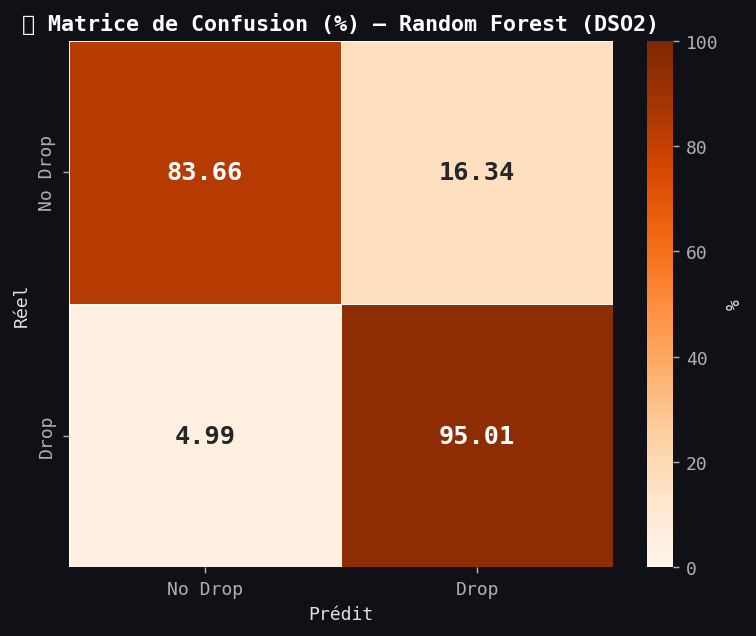

VN:83.7% FP:16.3% FN:5.0% VP:95.0%


In [9]:
# ── Matrice de Confusion — Random Forest ─────────────────────
cm_rf  = confusion_matrix(y_test, y_pred_rf)
cm_pct = cm_rf.astype('float') / cm_rf.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_pct*100, annot=True, fmt='.2f', cmap='Oranges',
    xticklabels=CM_LABELS, yticklabels=CM_LABELS,
    linewidths=0.5, ax=ax,
    annot_kws={'size':14,'weight':'bold'},
    cbar_kws={'label':'%'}, vmin=0, vmax=100)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title('📊 Matrice de Confusion (%) — Random Forest (DSO2)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_rf_dso2_pct.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f"VN:{cm_pct[0,0]*100:.1f}% FP:{cm_pct[0,1]*100:.1f}% "
      f"FN:{cm_pct[1,0]*100:.1f}% VP:{cm_pct[1,1]*100:.1f}%")

---
## Section 5 — M4 : BiLSTM


In [10]:
print('='*60+'\n  M4 — BiLSTM DSO2\n'+'='*60)

# ✅ CORRECTION BUG: '_t-{k}' → '_T{k}'
# NB2 génère rsrp_T1, rsrp_T2... (majuscule, sans tiret)
WINDOW_COLS = [
    c for c in COLS_X
    if any(f'_T{k}' in c for k in range(1, 6))  # ← CORRIGÉ
]
print(f'  WINDOW_COLS: {len(WINDOW_COLS)} colonnes')
print(f'  Exemples: {WINDOW_COLS[:5]}')

T = 5 if WINDOW_COLS else 1
if WINDOW_COLS:
    w_idx   = [list(COLS_X).index(c) for c in WINDOW_COLS]
    F       = len(w_idx) // T
    X_tr_3d = X_train[:, w_idx].reshape(-1, T, F)
    X_va_3d = X_val[:,   w_idx].reshape(-1, T, F)
    X_te_3d = X_test[:,  w_idx].reshape(-1, T, F)
else:
    print('  ⚠️ WINDOW_COLS vide → fallback T=1')
    F       = X_train.shape[1]; T = 1
    X_tr_3d = X_train.reshape(-1, 1, F)
    X_va_3d = X_val.reshape(-1,   1, F)
    X_te_3d = X_test.reshape(-1,  1, F)

print(f'  Shape 3D: {X_tr_3d.shape}')

tf.random.set_seed(42)
inp = Input(shape=(T, F))
x   = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(inp)
x   = BatchNormalization()(x)
x   = Bidirectional(LSTM(64, return_sequences=False, dropout=0.2))(x)
x   = BatchNormalization()(x)
x   = Dense(64, activation='relu')(x)
x   = Dropout(0.3)(x)
out = Dense(1, activation='sigmoid')(x)

lstm_d2 = Model(inputs=inp, outputs=out, name='BiLSTM_DSO2')
lstm_d2.compile(
    optimizer=Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['AUC']
)

sw = np.where(y_train == 1, ratio, 1).astype(np.float32)
history_d2 = lstm_d2.fit(
    X_tr_3d, y_train,
    validation_data=(X_va_3d, y_val),
    sample_weight=sw,
    epochs=30, batch_size=2048, verbose=1,
    callbacks=[
        EarlyStopping(
            monitor='val_AUC', patience=5,
            restore_best_weights=True, mode='max'
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6
        ),
        ModelCheckpoint(
            os.path.join(MODEL_OUT_DIR,'lstm_dso2_best.h5'),
            monitor='val_AUC', save_best_only=True, mode='max'
        )
    ]
)

y_prob_lstm = lstm_d2.predict(
    X_te_3d, batch_size=4096, verbose=0
).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)
print(classification_report(y_test, y_pred_lstm, target_names=CM_LABELS))

metrics_lstm = {
    'model':     'BiLSTM',
    'f1':        round(f1_score(y_test, y_pred_lstm), 4),
    'precision': round(precision_score(y_test, y_pred_lstm), 4),
    'recall':    round(recall_score(y_test, y_pred_lstm), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_lstm), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_lstm), 4)
}
# ✅ même nom que l'original
lstm_d2.save(os.path.join(MODEL_OUT_DIR,'lstm_dso2.h5'))
print(f"  BiLSTM F1={metrics_lstm['f1']}")

  M4 — BiLSTM DSO2
  WINDOW_COLS: 45 colonnes
  Exemples: ['rsrp_T1', 'rsrp_T2', 'rsrp_T3', 'rsrp_T4', 'rsrp_T5']
  Shape 3D: (8822003, 5, 9)
Epoch 1/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - AUC: 0.8684 - loss: 0.8139   

4308/4308 ━━━━━━━━━━━━━━━━━━━━ 1451s 327ms/step - AUC: 0.9068 - loss: 0.6863 - val_AUC: 0.9433 - val_loss: 0.2449 - learning_rate: 0.0010
Epoch 2/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 1445s 335ms/step - AUC: 0.9288 - loss: 0.5767 - val_AUC: 0.9385 - val_loss: 0.2521 - learning_rate: 0.0010
Epoch 3/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 2637s 612ms/step - AUC: 0.9334 - loss: 0.5556 - val_AUC: 0.9401 - val_loss: 0.2526 - learning_rate: 0.0010
Epoch 4/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 901s 209ms/step - AUC: 0.9358 - loss: 0.5443 - val_AUC: 0.9412 - val_loss: 0.2481 - learning_rate: 0.0010
Epoch 5/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 1285s 298ms/step - AUC: 0.9385 - loss: 0.5300 - val_AUC: 0.9407 - val_loss: 0.2544 - learning_rate: 5.0000e-04
Epoch 6/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 864s 200ms/step - AUC: 0.9395 - loss: 0.5254 - val_AUC: 0.9431 - val_loss: 0.2578 - learning_rate: 5.0000e-04
              precision    recall  f1-score   support

     No Drop       0.99      0.83      0.91   1824958
  

  BiLSTM F1=0.2634


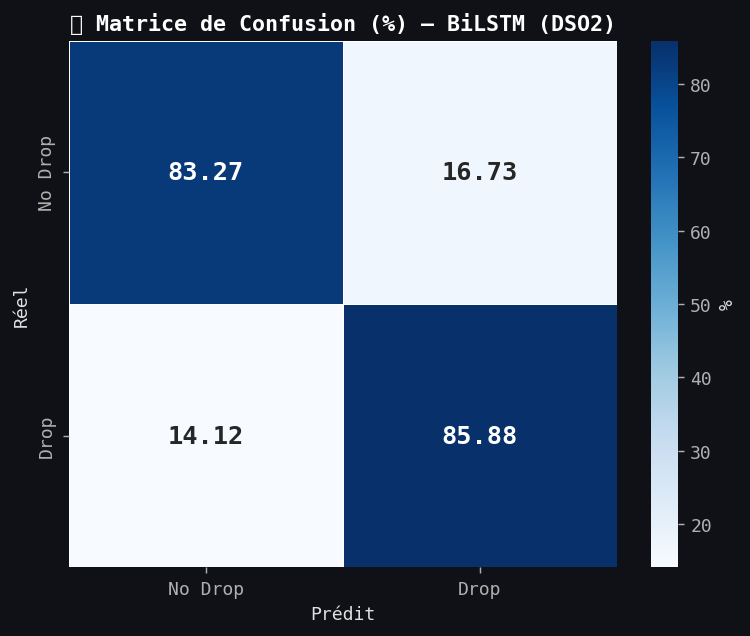

VN:83.3% FP:16.7% FN:14.1% VP:85.9%


In [11]:
# ── Matrice de Confusion — BiLSTM ────────────────────────────
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
cm_pct  = cm_lstm.astype('float') / cm_lstm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_pct*100, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CM_LABELS, yticklabels=CM_LABELS,
    linewidths=0.5, ax=ax,
    annot_kws={'size':14,'weight':'bold'}, cbar_kws={'label':'%'})
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title('📊 Matrice de Confusion (%) — BiLSTM (DSO2)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_lstm_dso2_pct.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f"VN:{cm_pct[0,0]*100:.1f}% FP:{cm_pct[0,1]*100:.1f}% "
      f"FN:{cm_pct[1,0]*100:.1f}% VP:{cm_pct[1,1]*100:.1f}%")

---
## Section 6 — M5 : TabNet


In [12]:
print('='*60+'\n  M5 — TabNet DSO2\n'+'='*60)

# ── 1. float32 + sampling ─────────────────────────────────────
N_TN       = min(100_000, len(X_train))
idx_tn     = np.random.choice(len(X_train), N_TN, replace=False)
X_tr_tn    = X_train[idx_tn].astype(np.float32)
X_va_tn    = X_val.astype(np.float32)
X_te_tn    = X_test.astype(np.float32)
y_train_tn = y_train[idx_tn]
print(f'Sample train: {len(X_tr_tn):,}')

# ── 2. Pretraining ────────────────────────────────────────────
# ✅ pretrainer défini AVANT son utilisation
pt_d2 = TabNetPretrainer(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=5, seed=42
)
pt_d2.fit(
    X_train=X_tr_tn,
    eval_set=[X_va_tn],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    pretraining_ratio=0.5
)

# ── 3. Modèle supervisé ───────────────────────────────────────
tabnet_d2 = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=0, seed=42
)

# Mini-fit pour initialiser le réseau
tabnet_d2.fit(
    X_train=X_tr_tn[:512],
    y_train=y_train_tn[:512].astype(int),
    max_epochs=1, batch_size=512, virtual_batch_size=512
)

# Transfert des poids encodeur
tabnet_d2.load_weights_from_unsupervised(pt_d2)

# ── 4. Entraînement réel ──────────────────────────────────────
tabnet_d2.verbose = 10
tabnet_d2.fit(
    X_train=X_tr_tn,
    y_train=y_train_tn.astype(int),
    eval_set=[(X_va_tn, y_val.astype(int))],
    eval_metric=['auc'],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    weights=1
)

# ── 5. Évaluation ─────────────────────────────────────────────
y_pred_tn = tabnet_d2.predict(X_te_tn)
y_prob_tn = tabnet_d2.predict_proba(X_te_tn)[:,1]
print(classification_report(y_test, y_pred_tn, target_names=CM_LABELS))

metrics_tn = {
    'model':     'TabNet',
    'f1':        round(f1_score(y_test, y_pred_tn), 4),
    'precision': round(precision_score(y_test, y_pred_tn), 4),
    'recall':    round(recall_score(y_test, y_pred_tn), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_tn), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_tn), 4)
}
# ✅ même nom que l'original
tabnet_d2.save_model(os.path.join(MODEL_OUT_DIR,'tabnet_dso2'))
print(f"  TabNet F1={metrics_tn['f1']}")

  M5 — TabNet DSO2
Sample train: 100,000
epoch 0  | loss: 2154.19941| val_0_unsup_loss_numpy: 24197.083984375|  0:04:26s
epoch 5  | loss: 2.08512 | val_0_unsup_loss_numpy: 187.87713623046875|  0:35:54s
epoch 10 | loss: 1.15928 | val_0_unsup_loss_numpy: 37.548648834228516|  0:49:47s
epoch 15 | loss: 1.01256 | val_0_unsup_loss_numpy: 5.757150173187256|  1:00:15s
epoch 20 | loss: 0.92667 | val_0_unsup_loss_numpy: 4.620100021362305|  1:11:29s

Early stopping occurred at epoch 24 with best_epoch = 19 and best_val_0_unsup_loss_numpy = 3.955399990081787
epoch 0  | loss: 0.57926 | val_0_auc: 0.88974 |  0:01:00s
epoch 10 | loss: 0.24691 | val_0_auc: 0.93757 |  0:13:06s

Early stopping occurred at epoch 17 with best_epoch = 12 and best_val_0_auc = 0.93998
              precision    recall  f1-score   support

     No Drop       1.00      0.81      0.89   1824958
        Drop       0.15      0.96      0.26     65474

    accuracy                           0.81   1890432
   macro avg       0.57   

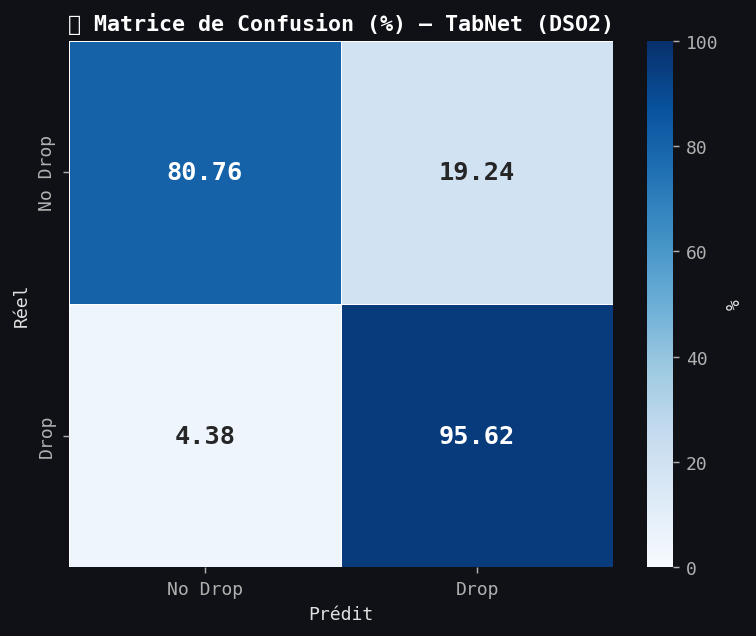

VN:80.8% FP:19.2% FN:4.4% VP:95.6%


In [13]:
# ── Matrice de Confusion — TabNet ────────────────────────────
cm_tn  = confusion_matrix(y_test, y_pred_tn)
cm_pct = cm_tn.astype('float') / cm_tn.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_pct*100, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CM_LABELS, yticklabels=CM_LABELS,
    linewidths=0.5, ax=ax,
    annot_kws={'size':14,'weight':'bold'},
    cbar_kws={'label':'%'}, vmin=0, vmax=100)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title('📊 Matrice de Confusion (%) — TabNet (DSO2)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_tabnet_dso2_pct.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f"VN:{cm_pct[0,0]*100:.1f}% FP:{cm_pct[0,1]*100:.1f}% "
      f"FN:{cm_pct[1,0]*100:.1f}% VP:{cm_pct[1,1]*100:.1f}%")

---
## Section 7 — Grille comparative & Dashboard


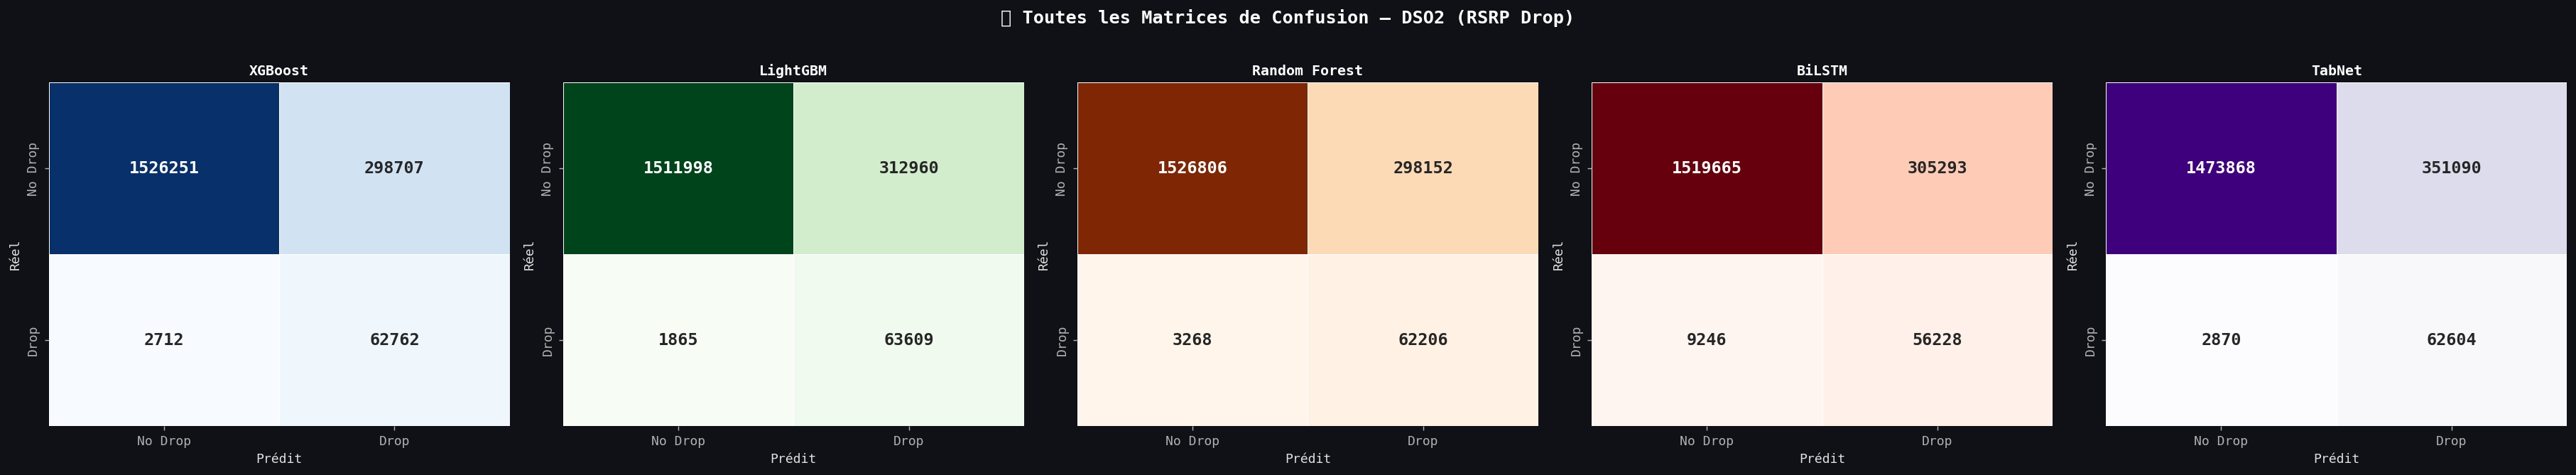


=== RÉSULTATS DSO2 ===
                   f1  precision  recall  auc_roc  auc_pr
model                                                    
XGBoost        0.2940     0.1736  0.9586   0.9544  0.4499
LightGBM       0.2878     0.1689  0.9715   0.9533  0.4423
Random Forest  0.2922     0.1726  0.9501   0.9486  0.4313
BiLSTM         0.2634     0.1555  0.8588   0.9078  0.2391
TabNet         0.2613     0.1513  0.9562   0.9278  0.2492

🏆 Meilleur (F1) : XGBoost → 0.2940


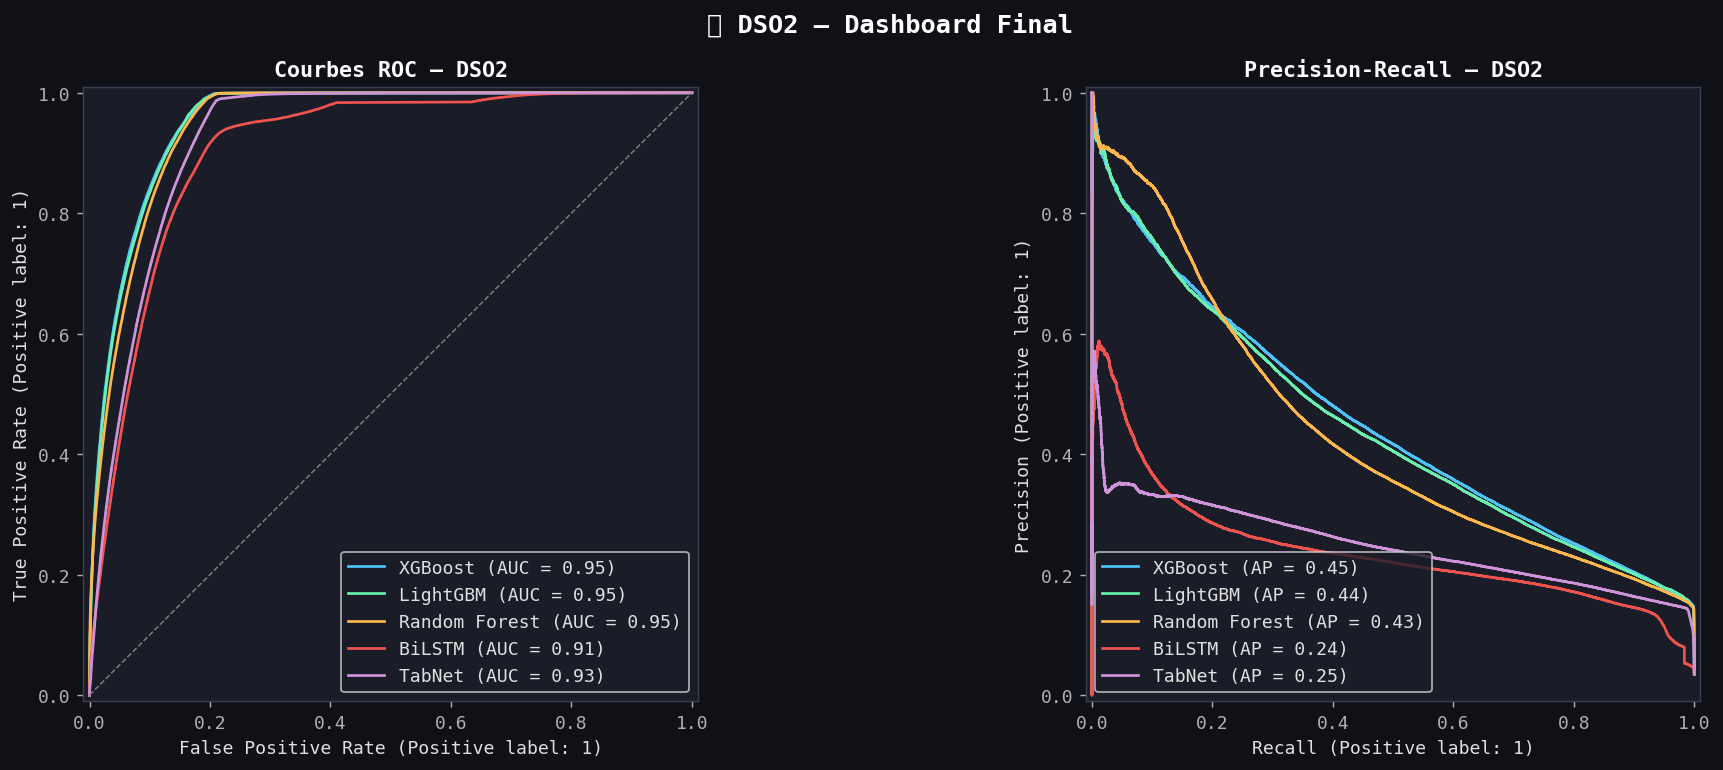


✅ results_dso2.json sauvegardé


In [14]:
# ── Grille comparative ────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(28,5))
models_cm = [
    ('XGBoost',      cm_xgb,  'Blues'),
    ('LightGBM',     cm_lgbm, 'Greens'),
    ('Random Forest',cm_rf,   'Oranges'),
    ('BiLSTM',       cm_lstm, 'Reds'),
    ('TabNet',       cm_tn,   'Purples')
]
for ax, (name, cm, cmap) in zip(axes, models_cm):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=CM_LABELS, yticklabels=CM_LABELS,
        linewidths=0.5, ax=ax,
        annot_kws={'size':13,'weight':'bold'}, cbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')

plt.suptitle(
    '🔢 Toutes les Matrices de Confusion — DSO2 (RSRP Drop)',
    fontsize=14, fontweight='bold', color='white', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_all_dso2.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

# ── Comparaison finale ────────────────────────────────────────
all_metrics = [metrics_xgb, metrics_lgbm, metrics_rf,
               metrics_lstm, metrics_tn]
df_results  = pd.DataFrame(all_metrics).set_index('model')
print('\n=== RÉSULTATS DSO2 ===')
print(df_results.to_string())

best = df_results['f1'].idxmax()
print(f'\n🏆 Meilleur (F1) : {best} → {df_results.loc[best,"f1"]:.4f}')

# Courbes ROC + PR
models_list = ['XGBoost','LightGBM','Random Forest','BiLSTM','TabNet']
probs_list  = [y_prob_xgb, y_prob_lgbm, y_prob_rf, y_prob_lstm, y_prob_tn]
colors_list = [BLUE, GREEN, ORANGE, RED, PURPLE]

fig, axes = plt.subplots(1, 2, figsize=(16,6))
for name, prob, color in zip(models_list, probs_list, colors_list):
    RocCurveDisplay.from_predictions(
        y_test, prob, name=name, ax=axes[0], color=color
    )
axes[0].set_title('Courbes ROC — DSO2', fontweight='bold')
axes[0].plot([0,1],[0,1],'--',color='gray',lw=0.8)

for name, prob, color in zip(models_list, probs_list, colors_list):
    PrecisionRecallDisplay.from_predictions(
        y_test, prob, name=name, ax=axes[1], color=color
    )
axes[1].set_title('Precision-Recall — DSO2', fontweight='bold')

plt.suptitle('🏆 DSO2 — Dashboard Final',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'dashboard_dso2.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

# ✅ même nom que l'original
with open(os.path.join(MODEL_OUT_DIR,'results_dso2.json'),'w') as f:
    json.dump(all_metrics, f, indent=2)
print('\n✅ results_dso2.json sauvegardé')

---
## Bilan NB4 DSO2 — Corrigé

### 📊 Label DSO2
```
rsrp_drop = 1  si  min(rsrp[t+1..t+5]) - rsrp[t] < -6 dBm
Calculé sur rsrp BRUT (df_final_fe.parquet)
PAS sur rsrp normalisé (df_preprocessed)
```

### ✅ Corrections apportées
| Correction | Avant | Après |
|------------|-------|-------|
| cluster_id | Non vérifié | ✅ Assert présent |
| BiLSTM colonnes T-5 | `_t-{k}` (bug) | ✅ `_T{k}` (format NB2) |
| Noms fichiers output | — | ✅ Identiques à l'original |

### 💾 Fichiers produits
```
MODEL_output/DSO2/
  xgb_dso2.pkl
  lgbm_dso2.pkl
  rf_dso2.pkl
  lstm_dso2.h5
  lstm_dso2_best.h5
  tabnet_dso2.zip
  results_dso2.json
  cm_all_dso2.png
  dashboard_dso2.png
```

### 🔗 Utilisation backend
```
lgbm_dso2.pkl → service-prediction :8001
  → dso2_flag = lgbm_d2.predict(X)[0]
  → 1 = drop RSRP imminent
  → label = "Dégradation signal imminente"
```
